# 01 Rl Applications

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply RL to games, control, or recommendation
- Identify reward design and environment interfaces

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 5**.

---


## Lesson Brief

This lesson shows students where reinforcement learning appears outside toy benchmarks.

The main goal is to help them recognize which real-world problems fit the RL pattern and which ones do not.

Why this matters: students should not leave the course thinking RL is only for games.

This notebook gives the application lens for the rest of Unit 5.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Reinforcement Learning in 3 Hours | Full Course using Python"**:
[Watch on YouTube](https://www.youtube.com/watch?v=Mut_u40Sqz4)

Suggested focus: the opening application overview before the coding sections.

Why this pick:
- practical explanation of where RL is actually used.
- Connects theory to games, robotics, trading, and control tasks.
- Good for widening student intuition beyond benchmark environments.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Application lens: translating a real task into RL.
- Objective: what success really means.
- Constraint: a real-world limit.
- Deployment gap: toy example versus real system.
- Reward misspecification: when the designed reward does not match the true goal.

### Quick Check
- How do states, actions, and rewards map to the real problem?
- Why is reward design harder in applications?
- What makes an application realistic?
- What can go wrong even if the agent optimizes the reward successfully?

### Common Mistakes
- Choosing an algorithm before formulating the problem.
- Ignoring constraints.
- Optimizing a proxy that is not the real goal.
- Forgetting that a system can maximize reward and still behave badly in practice.


## Big Idea

By Unit 5, the question is no longer only *how an RL algorithm works*.

Now the question becomes:

- where is RL actually useful?
- how do we formulate real applications?
- what makes deployment difficult in practice?

## Application Framing Before Algorithm Choice

One of the biggest mistakes in advanced RL is asking:

`Which algorithm should I use?`

before asking:

`Is this really an RL problem, and how should I formulate it?`

### The right order

1. define the state
2. define the actions
3. define the reward
4. identify constraints and safety risks
5. only then discuss algorithms

### Why this matters

In real systems, poor formulation can ruin the project even if the learning algorithm is mathematically correct.

A badly chosen reward can produce harmful behavior, and a missing constraint can make deployment unsafe.

### Teaching takeaway

Unit 5 is not only about seeing more examples.
It is about learning how to think like a designer of RL systems, not only a user of RL algorithms.

## Application Lens

For each application, ask five questions:

1. What is the state?
2. What actions are available?
3. What reward is optimized?
4. What makes the environment difficult?
5. What safety or ethical risks appear?

### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Save a value in a name so the next lines can read it.
applications = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "games": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "state": "board position or observation frame",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "action": "move or control command",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "reward": "score, win signal, survival",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "challenge": "long horizons and sparse rewards",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "robotics": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "state": "joint positions, velocities, sensor readings",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "action": "motor torques or control commands",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "reward": "stability, speed, task completion",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "challenge": "safety and sim-to-real transfer",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "recommendation": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "state": "user context and interaction history",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "action": "item or content recommendation",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "reward": "click, watch time, conversion, retention",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "challenge": "delayed rewards and user feedback loops",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "resource optimization": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "state": "current demand, supply, system load",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "action": "allocation or scheduling decision",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "reward": "efficiency, cost reduction, throughput",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "challenge": "constraints and changing conditions",
    # Execute: },
    },
# Part of a dict/set literal layout (syntax grouping).
}

# Start a loop: repeat the indented block once per item in the sequence.
for name, details in applications.items():
    # Show text or numbers in the cell output area under the code.
    print(f"\nApplication: {name}")
    # Start a loop: repeat the indented block once per item in the sequence.
    for key, value in details.items():
        # Show text or numbers in the cell output area under the code.
        print(f"  {key.title()}: {value}")



Application: games
  State: board position or observation frame
  Action: move or control command
  Reward: score, win signal, survival
  Challenge: long horizons and sparse rewards

Application: robotics
  State: joint positions, velocities, sensor readings
  Action: motor torques or control commands
  Reward: stability, speed, task completion
  Challenge: safety and sim-to-real transfer

Application: recommendation
  State: user context and interaction history
  Action: item or content recommendation
  Reward: click, watch time, conversion, retention
  Challenge: delayed rewards and user feedback loops

Application: resource optimization
  State: current demand, supply, system load
  Action: allocation or scheduling decision
  Reward: efficiency, cost reduction, throughput
  Challenge: constraints and changing conditions


## Which applications fit RL best?

RL is strongest when:

- decisions are sequential
- actions change future states
- feedback arrives over time
- a fixed supervised label is not enough

RL is weaker when the problem is one-shot, fully labeled, or unsafe to explore directly.

### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Save a value in a name so the next lines can read it.
scores = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "games": 5,
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "robotics": 4,
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "recommendation": 4,
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "resource optimization": 5,
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "static image classification": 1,
# Part of a dict/set literal layout (syntax grouping).
}

# Show text or numbers in the cell output area under the code.
print("Sequential-decision suitability score (1=weak, 5=strong):")
# Start a loop: repeat the indented block once per item in the sequence.
for name, score in scores.items():
    # Show text or numbers in the cell output area under the code.
    print(f"- {name}: {score}")


Sequential-decision suitability score (1=weak, 5=strong):
- games: 5
- robotics: 4
- recommendation: 4
- resource optimization: 5
- static image classification: 1


## Common deployment risks

Before deploying RL in the real world, check for:

- reward hacking
- unsafe exploration
- unfair or manipulative behavior
- poor robustness under shift
- misleading evaluation metrics

## Worked Comparison

The short case study below is not about mastering one algorithm.
It is about seeing how the same RL thinking pattern appears across domains.

## Worked Example: Comparing Application Formulations

Below we compare three application domains at the formulation level:

- recommendation
- robotics
- inventory/resource optimization

The goal is to understand the *problem framing* before choosing the algorithm.

### Step Guide

**What this cell does:** Summarize or compare results (policies, returns, tables) for the lesson goal.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Tables, arrays, or comparison prints showing which policy or method wins.

**If you feel lost:** If output is empty, run the previous cells that define the data this cell consumes.


In [3]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Save a value in a name so the next lines can read it.
application_table = [
    # Execute: ["Recommendation", "user profile + history", "recommend item", "engagement / retention", " …
    ["Recommendation", "user profile + history", "recommend item", "engagement / retention", "filter bubbles"],
    # Execute: ["Robotics", "robot state + sensors", "motor command", "task success + stability", "unsafe …
    ["Robotics", "robot state + sensors", "motor command", "task success + stability", "unsafe exploration"],
    # Execute: ["Inventory", "stock + demand signal", "reorder decision", "profit - cost - shortage", "re …
    ["Inventory", "stock + demand signal", "reorder decision", "profit - cost - shortage", "reward misspecification"],
# Execute: ]
]

# Save a value in a name so the next lines can read it.
headers = ["Domain", "State", "Action", "Reward", "Risk"]
# Show text or numbers in the cell output area under the code.
print(" | ".join(headers))
# Show text or numbers in the cell output area under the code.
print("-" * 120)
# Start a loop: repeat the indented block once per item in the sequence.
for row in application_table:
    # Show text or numbers in the cell output area under the code.
    print(" | ".join(row))

# Show text or numbers in the cell output area under the code.
print("\nDiscussion prompt:")
# Show text or numbers in the cell output area under the code.
print("Notice that the algorithm is not the first design decision.")
# Show text or numbers in the cell output area under the code.
print("The first decision is how to represent the sequential decision problem well.")


Domain | State | Action | Reward | Risk
------------------------------------------------------------------------------------------------------------------------
Recommendation | user profile + history | recommend item | engagement / retention | filter bubbles
Robotics | robot state + sensors | motor command | task success + stability | unsafe exploration
Inventory | stock + demand signal | reorder decision | profit - cost - shortage | reward misspecification

Discussion prompt:
Notice that the algorithm is not the first design decision.
The first decision is how to represent the sequential decision problem well.


## Summary

This notebook is about **application thinking**.

### Main takeaways

- RL fits problems with sequential decisions and delayed consequences.
- The first design work is defining state, action, reward, and evaluation.
- Deployment risks matter as much as benchmark performance.
- Real applications often require safety, fairness, and robustness thinking before deployment.

### Next step

Continue to the later Unit 5 notebooks to study multi-agent RL, hierarchical RL,
and model-based RL as extensions of this application lens.

In [4]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


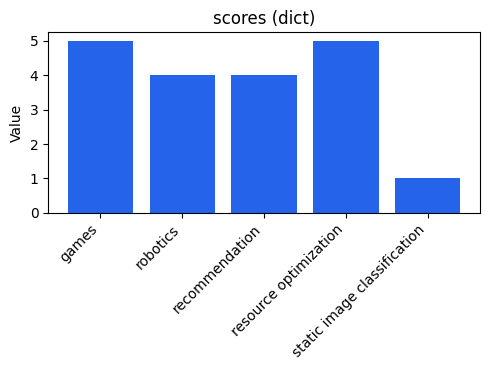

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Real RL applications begin by matching the problem structure to the right decision framework, constraints, and success metric.

**If students remember one idea:** An application is not automatically a good RL problem. Students must ask what is sequential, what is uncertain, and what feedback is available.

**Quick check before moving on:**
- Can you explain what makes a practical problem suitable for RL?
- Can you describe when a non-RL approach may actually be the better choice?

**Bridge to the next step:** The next lessons make this concrete through specific application areas such as games and resource allocation.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=4 | term=True | trunc=False


objc[77729]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113914138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x113e549c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77729]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113914188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x113e54a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77729]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113913c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x113e54a68). T

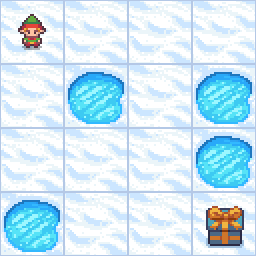

In [6]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
